<a href="https://colab.research.google.com/github/fpinell/hands_on_python_for_ds/blob/main/notebooks/master/Lecture_2_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 2 — Supervised Learning


- ### PhD IMT School for advanced studies Lucca


#### Fabio Pinelli
<a href="mailto:fabio.pinelli@imtlucca.it">fabio.pinelli@imtlucca.it</a><br/>
IMT School for Advanced Studies Lucca<br/>
2025/2026<br/>
May, 13 2026

# Today lesson

- How to organize a ML project and the steps you need to perform
- Regression
- Classification

... and some scikit-learn functionalities to authomatize the ML process.

# Taxonomy of ML

-  Roughly speaking there are two main **categories** of ML tasks:

    1.  **Supervised Learning**: Given a set of **labeled** examples, **predict** the labels of _new and unseen_ examples
    2.  **Unsupervised Learning**: Given a set of examples, **find structure** in the data (e.g., _clusters_, _subspaces_, _manifolds_)

## Supervised learning
The main difference between **Regression** and **Classification** algorithms that:
- **Regression** algorithms are used to predict the _continuous values_ such as price, salary, age, etc. and
- **Classification** algorithms are used to predict/classify the _discrete values_ such as Male or Female, True or False, Spam or Not Spam, etc.



# Check list for a Machine Learning project

1. Understand the problem.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
  - split on training and test
  - handling missing values
  - categorical values
  - scaling
  - etc.
5. Compare different models, choose the best and train it.
6. Fine-tune your model.
7. Present your solution.
  - stakeholder
  - paper
  - supervisor
  - etc.



#### Scikit API introduction

- Consinstency: All objects share a consistent and simple interface
  + Estimators:
    - Any object that can estimate some parameters based on a dataset
is called an _estimator_
    - It uses the fit() and it takes only the dataset as parameters, the others are considered hyperparameters.
  + Transformers: Some estimators can transform the dataset.
    - transform() method with the dataset to transform as a parameter.
    - fit_transform() to perform both operation at once (more quick)
  + Predictors: estimators that make predictions
    - predict() method that takes a dataset of new instances and returns a dataset of corresponding predictions.
    - score() to measure the quality of the predictions
- Inspection --> two types of access to relevant information
  + All the estimator’s **hyperparameters** are accessible directly via **public
instance variables**
  + all the estimator’s **learned** parameters are also accessible via public instance variables with an **underscore suffix**
- Nonproliferation of classes
  +  Datasets are represented as NumPy arrays or SciPy sparse matrices, instead of homemade classes
- Composition: Create pipelines
- Sensible defaults: scikit provides reasonable default values for most
parameters, making it easy to create a baseline working system quickly

## Understand the problem.

### A regression  problem

We load a dataset of rental listings in Milan (`rentals_milan.csv`), enriched with per-neighborhood features from `zones_milan.csv` (distance to the Duomo, average income, public-transport score). The target is the **monthly rent in €**, a *continuous* value, so this is a **regression** task.

The data is intentionally messy: prices like `"€ 950"`, mixed date formats, inconsistent casing in `neighborhood` and `furnishing`, the `floor` column mixes integers with strings like `"first"`, `"ground floor"`, `"5th"`. Part of the work is cleaning it.


In [ ]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os



# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

import seaborn as sns


# Where to save the figures
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

# from google.colab import drive
# drive.mount('/content/drive')

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Get the data

We have two CSVs in the repo's `data/` folder:
- `rentals_milan.csv` — one row per listing
- `zones_milan.csv` — one row per neighborhood with `distance_duomo_km`, `avg_income_eur`, `transport_score`

We will join them on the (normalized) neighborhood name.

In Colab:
``` python
from google.colab import drive
drive.mount('/content/drive')
```


In [ ]:
import re, pathlib

# Locate the data directory (works locally from the repo, or on Colab)
candidate_dirs = [
    pathlib.Path('data'),
    pathlib.Path('../../../data'),
    pathlib.Path('/content/drive/Shareddrives/phd_hands_on/data/milan'),
]
DATA_DIR = next(p for p in candidate_dirs if (p / 'rentals_milan.csv').exists())

rentals = pd.read_csv(DATA_DIR / 'rentals_milan.csv')
zones   = pd.read_csv(DATA_DIR / 'zones_milan.csv')

# --- Minimal type cleanup so describe()/hist() work ---
# 1) price: strip euro sign, cast to float
rentals['price'] = (rentals['price'].astype(str)
                                   .str.replace('€', '', regex=False)
                                   .str.replace(',', '.', regex=False)
                                   .str.strip()
                                   .astype(float))

# 2) floor: "first", "5th", "ground floor", "3" -> int
def _parse_floor(x):
    if pd.isna(x): return np.nan
    s = str(x).lower().strip()
    if 'ground' in s: return 0
    if 'first' in s: return 1
    m = re.search(r'\d+', s)
    return float(m.group()) if m else np.nan
rentals['floor'] = rentals['floor'].apply(_parse_floor)

# 3) neighborhood: normalize casing/whitespace, drop optional "Zone " prefix
def _norm_n(s):
    if pd.isna(s): return s
    return re.sub(r'^zone\s+', '', str(s).strip().lower())
rentals['neighborhood'] = rentals['neighborhood'].apply(_norm_n)
zones['neighborhood']   = zones['neighborhood'].apply(_norm_n)

# 4) furnishing & heating: normalize spellings
def _norm_furn(x):
    if pd.isna(x): return x
    s = str(x).lower().strip().rstrip('.')
    if 'partly' in s or 'partial' in s: return 'partly furnished'
    if s.startswith('un'): return 'unfurnished'
    if 'furn' in s: return 'furnished'
    return s
rentals['furnishing'] = rentals['furnishing'].apply(_norm_furn)
rentals['heating'] = (rentals['heating'].astype(str).str.lower().str.strip()
                       .replace({'hp': 'heat pump', 'nan': np.nan}))

# 6) sqm: some rows contain strings like "76 sqm" — strip non-digits
rentals['sqm'] = (rentals['sqm'].astype(str)
                                .str.extract(r'(\d+(?:\.\d+)?)')[0]
                                .astype(float))

# 5) Join in the per-neighborhood features
rentals = rentals.merge(zones, on='neighborhood', how='left')


In [ ]:
rentals.head()

In [ ]:
print('N. of rows: {}'.format(rentals.shape[0]))
print('N. of columns: {}'.format(rentals.shape[1]))
print('The columns contained in our first dataframe are:\n{}'.format(
    ',\n'.join('{}. {}'.format(i, c) for i, c in enumerate(rentals.columns))
))

In [ ]:
rentals.info()

We expect output similar to:

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: ~2513 entries
Data columns include:
 #   Column              Dtype
---  ------              -----
 0   id                  object
 1   listing_date        object       <-- mixed date formats
 2   neighborhood        object
 3   price               float64
 4   sqm                 int64
 5   rooms               int64
 6   bedrooms            int64
 7   bathrooms           int64
 8   floor               float64      <-- cleaned from messy strings
 9   elevator            bool
 10  furnishing          object
 11  heating             object
 12  energy_class        object       <-- some NaN
 13  year_built          float64      <-- some NaN
 14  nearest_metro       object       <-- some NaN
 15  condo_fees          float64      <-- some NaN
 16  deposit_months      int64
 17  contract_type       object
 18  description         object
 19  distance_duomo_km   float64      <-- from zones
 20  avg_income_eur      int64        <-- from zones
 21  transport_score     int64        <-- from zones
```


Several columns present peculiarities:

- `year_built`, `condo_fees`, `energy_class`, `nearest_metro` — contain **missing values**
- `listing_date` — contains **mixed date formats** that we'll skip for modelling
- `nearest_metro`, `furnishing`, `heating`, `energy_class`, `contract_type`, `neighborhood` — are **categorical**

Do you know how to deal with these?


In [ ]:
rentals["neighborhood"].value_counts()

In [ ]:
rentals

In [ ]:
# Drop listings with no price (our target) — analog to dropping odd categories.
rentals = rentals[rentals["price"].notna()].copy()

In [ ]:
rentals.shape

In [ ]:
rentals.reset_index(inplace=True, drop=True)

In [ ]:
rentals.describe()

## Explore the data and visualize

It helps to identify peculierities in our datasets, and if we -- data scientist -- we need to take into account some specificity that we highlight through some simple visualization plots.

In [ ]:
'''
We call hist() function defined for pandas dataframes.
It's a Pandas function that generates histograms for numerical features
'''

rentals.hist(bins=50, figsize=(20, 15))
plt.show()

### Some comments on the data

1. The **price** distribution is heavily right-skewed: most rents cluster between 800 and 2000 €, but there is a long tail of expensive listings. ML algorithms can struggle with tail-heavy targets.
2. **sqm**, **condo_fees** are also right-skewed.
3. **avg_income_eur** and **distance_duomo_km** were joined from the zone table — they take only ~20 distinct values (one per neighborhood).
4. The features are on very different scales (rooms in single digits, prices in thousands, income in tens of thousands). We will need to **scale** them before fitting linear models.


We discussed some other functions to easily and quickly visualize the data of our dataframes.

- Correlation Matrix
- Seaborn pairplots
- KDE

In [ ]:
# tipically we group by the classes when we deal with a classification task
# In any case, we could see if there are any interesting pattern emerging, or differences in the distributions.
plot = True
if plot:
    cols = ['price', 'sqm', 'rooms', 'distance_duomo_km', 'avg_income_eur', 'contract_type']
    _ = sns.pairplot(rentals[cols].sample(min(1500, len(rentals)), random_state=42),
                     hue='contract_type')

In [ ]:
'''
Another check that we could do is to verify if features have strong correlation among them or with the target variable
'''

corr = rentals.corr('pearson', numeric_only=True)
_ = sns.heatmap(corr, annot=True, cmap="YlGnBu")

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["price", "sqm", "avg_income_eur", "distance_duomo_km"]
_ = scatter_matrix(rentals[attributes], figsize=(12, 8))

In [ ]:
'''
We can check which features have a greater correlation with the target variable
'''
corr["price"].sort_values(ascending=False)

In [ ]:
'''
Among the numeric features, `sqm` and `avg_income_eur` are typically the most correlated with `price`.
Let's look at the scatter for sqm vs price.

You'll likely notice some horizontal striping (round-number rents like 1000, 1500, 2000) — a real-world data artifact a data scientist must decide how to handle.
'''

_ = rentals.plot(kind='scatter', x='sqm', y='price', alpha=.1)

In [ ]:
'''
We don't have latitude/longitude, but we do have `distance_duomo_km` and `transport_score`
from the zones table — a coarse "geography" of Milan.
'''

rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score")

In [ ]:
'''
With alpha we can see where listings concentrate: most are close to the Duomo and in
well-connected zones.
'''

rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score", alpha=0.1)

In [ ]:
'''
Let's color by price and size by sqm.
Distance to the Duomo and transport quality both influence the rent.
'''

_ = rentals.plot(kind="scatter", x="distance_duomo_km", y="transport_score", alpha=0.4,
                 s=rentals["sqm"] / 2, label="sqm", figsize=(10, 7),
                 c="price", cmap=plt.get_cmap("jet"), colorbar=True,
                 sharex=False)
plt.legend()

## Data preparation

### Split in training and test.

Scikit-learn provides to the developers a series of function that can be used to split the original dataset in training and test.

- ***__Training__*** is the set used to train our model together with the relative pipeline
- ***__Test__*** is the dataset that shouldn't be touched until the very end of the ML process. Everything needs to be "learned" from the training set (e.g. imputing value for an inputer)

In [ ]:
from sklearn.model_selection import train_test_split

'''
1. random_state to get the same dataset split in different runs.
2. test_size the proportion of the dataset that we want to preserve for test, the rest is for training.
3. This is a purely random --> can introduce a significant sampling bias
'''

train_set, test_set = train_test_split(rentals, test_size=0.2, random_state=42)

In [ ]:
print(train_set.shape)
print(test_set.shape)
print(rentals.shape)

We can imagine that **`avg_income_eur`** (the neighborhood's average income) is an important feature to predict rent. Thus:

+ We want to avoid a sample bias between training and test.
+ Ensure that the test set is representative of the various income strata in the whole dataset.

--->  ***stratified sampling***: the population is divided into homogeneous subgroups called strata, and the right number of instances is sampled from each stratum to guarantee that the test set is representative of the overall population

In order to use `avg_income_eur` as a categorical value we need to create a new column using a special function of pandas... do you remember?


In [ ]:
'''
pd.cut creates bins and assigns each row to a specific bin given the intervals provided to the function.
'''

rentals["income_cat"] = pd.cut(rentals["avg_income_eur"],
                               bins=[0, 35000, 42000, 50000, np.inf],
                               labels=[1, 2, 3, 4])

In [ ]:
'''
Check the frequency of the new values
'''

rentals["income_cat"].value_counts()

In [ ]:
'''
and here the relative plot
'''
_ = rentals["income_cat"].hist()

In [ ]:
'''
Now that we have a column with discrete values, it is easier to preserve the distributions between training and test set.
Scikit provides StratifiedShuffleSplit

Provides train/test indices to split data in train/test sets.

This cross-validation object is a merge of StratifiedKFold and
ShuffleSplit, which returns stratified randomized folds
'''

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(rentals, rentals["income_cat"]):
    strat_train_set = rentals.loc[train_index]
    strat_test_set = rentals.loc[test_index]

In [ ]:
'''
Let's check if the proportion of income_cat is maintained between test and training
'''
print(strat_test_set["income_cat"].value_counts() / len(strat_test_set))
print(strat_train_set["income_cat"].value_counts() / len(strat_train_set))

In [ ]:
'''
We can compare the results with the pure random split
'''

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(rentals, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall":      income_cat_proportions(rentals),
    "Stratified":   income_cat_proportions(strat_test_set),
    "Random":       income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"]  = 100 * compare_props["Random"]     / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
compare_props

In [ ]:
'''
And finally we can drop the created column
'''

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### Feature engineering

In [ ]:
'''
Another strategy to enrich the dataset is to create new features defined as combinations of existing ones.

For Milan rentals, useful derived attributes are:
- sqm_per_room  (how spacious each room is)
- bedrooms_per_room (ratio of bedrooms to total rooms)
- age (how old the building is, derived from year_built)
'''

# arithmetic combinations of existing columns
rentals["sqm_per_room"]      = rentals["sqm"]      / rentals["rooms"]
rentals["bedrooms_per_room"] = rentals["bedrooms"] / rentals["rooms"]
rentals["age"]               = 2025 - rentals["year_built"]

In [ ]:
'''
And now we can check if we found some interesting correlation with the target variable and the new ones.
'''

corr_matrix = rentals.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

1. **sqm_per_room** and **bedrooms_per_room** capture the "shape" of the apartment beyond just the raw counts.
2. **age** (newer buildings) often correlates with energy efficiency and rent.
3. As in the California example, simple arithmetic combinations can reveal patterns that the raw features do not expose directly.

In [ ]:
'''
From now on we will use the strat_train_set as DataFrame
'''

rentals = strat_train_set.drop("price", axis=1)         # drop labels for training set
rentals_labels = strat_train_set["price"].copy()        # our labels

### Data cleaning

#### Missing values

• Get rid of the corresponding districts.
  - ``` housing.dropna(subset=["total_bedrooms"]) ```

• Get rid of the whole attribute.

  - ```housing.drop("total_bedrooms", axis=1) ```

• Set the values to some value (zero, the mean, the median, etc.).
  - ``` median = housing["total_bedrooms"].median() ```
  - ``` housing["total_bedrooms"].fillna(median, inplace=True) ```
  - compute the median value on the training set, and use that value to replace missing values in the test set when you want to evaluate your system

For this last option scikit provides a simple class <code>SimpleImputer</code>

--> This allows us to perform all the *transformations* of our dataset only using Scikit-learn

In [ ]:
sample_incomplete_rows = rentals[rentals.isnull().any(axis=1)].head()
sample_incomplete_rows

In [ ]:
sample_incomplete_rows.dropna(subset=["year_built"])    # option 1

In [ ]:
sample_incomplete_rows.drop("year_built", axis=1)       # option 2

In [ ]:
median = rentals["year_built"].median()
print("The median of year_built is {}".format(median))
sample_incomplete_rows["year_built"].fillna(median, inplace=True)   # option 3
sample_incomplete_rows

In [ ]:
'''
Use the scikit class SimpleImputer.

First, we create an instance of that type of object using a median as the strategy.
'''

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# We drop the non-numerical columns/features/attributes (and the free-text/date columns).
non_numeric = ["id", "listing_date", "neighborhood", "furnishing", "heating",
               "energy_class", "nearest_metro", "contract_type", "description",
               "income_cat"]
rentals_num = rentals.drop(columns=[c for c in non_numeric if c in rentals.columns])

# We fit the imputer on the sub-set just created.
imputer.fit(rentals_num)

In [ ]:
'''
The Imputer has simply computed the median of each attribute and stored the result
in its statistics_ instance variable.

Several attributes had missing values (year_built, condo_fees, floor, ...), but we cannot be sure
that there won't be any missing values in new data after the system goes live, so it is safer
to apply the imputer to all the numerical attributes.
'''

imputer.statistics_

In [ ]:
'''
Now we can transform our dataset
'''
X = imputer.transform(rentals_num)
print(type(X))

# we create a new dataframe since the result of the transform operation is a numpy array.
rentals_tr = pd.DataFrame(X, columns=rentals_num.columns, index=rentals_num.index)

In [ ]:
rentals_tr.info()

#### Categorical values

Most Machine Learning algorithms prefer to work with numbers anyway, so let's convert these categories from text to numbers.

There are different strategies and it depends on the categorical column.

For our dataset:
- `energy_class` (A, B, C, D, E, F, G) has a **natural ordering** — a good case for `OrdinalEncoder`.
- `nearest_metro` (M1, M2, M3, M5) has no natural order — a good case for `OneHotEncoder`.

In [ ]:
rentals_cat = rentals[["energy_class"]].fillna("UNKNOWN")
rentals_cat.head(15)

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
rentals_cat_encoded = ordinal_encoder.fit_transform(rentals_cat)
rentals_cat_encoded[:10]

In [ ]:
ordinal_encoder.categories_

In [ ]:
from sklearn.preprocessing import OneHotEncoder

rentals_cat_metro = rentals[["nearest_metro"]].fillna("NONE")

cat_encoder = OneHotEncoder()
rentals_cat_1hot = cat_encoder.fit_transform(rentals_cat_metro)
rentals_cat_1hot

In [ ]:
cat_encoder = OneHotEncoder(sparse_output=False)
rentals_cat_1hot = cat_encoder.fit_transform(rentals_cat_metro)
rentals_cat_1hot

Given the flexibility of scikit, and the API structure, it is possible to define Custom Transformers.

All we need is to create a class with three methods:
1. fit() --> return self
2. transform()
3. fit_transform()

In our case, we can use a custom transformer for the creation of the new attributes defined as a combination of attributes.

In [ ]:
'''
TransformerMixin already provides fit_transform for free.

Adding BaseEstimator we get two extra methods get_params() and set_params()
These can be useful for automatic hyperparameter tuning.

`add_bedrooms_per_room` is the only hyperparameter; it lets us check whether that derived
feature actually helps the model.
'''

from sklearn.base import BaseEstimator, TransformerMixin

# column indices in rentals_num (numeric subset)
sqm_ix      = list(rentals_num.columns).index("sqm")
rooms_ix    = list(rentals_num.columns).index("rooms")
bedrooms_ix = list(rentals_num.columns).index("bedrooms")
year_ix     = list(rentals_num.columns).index("year_built")

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        sqm_per_room = X[:, sqm_ix] / X[:, rooms_ix]
        age          = 2025 - X[:, year_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, sqm_per_room, age, bedrooms_per_room]
        else:
            return np.c_[X, sqm_per_room, age]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
rentals_extra_attribs = attr_adder.transform(rentals_num.values)

#### Feature scaling

- **Min-max** scaling (many people call this **normalization**) is quite simple: values are shifted and rescaled so that they end up ranging from 0 to 1 -
  +  ```MinMaxScaler()```

- **Standardization** is quite different: first it subtracts the mean value (so standardized values always have a zero mean), and then it divides by the standard deviation so that the resulting distribution has unit variance. Unlike min-max scaling, standardization does not bound values to a specific range, which may be a problem for some algorithms
 + ```StandardScaler()```

 Notice that it is important to fit the scalers to the **training data only**, not to the full dataset (including the test set).
Only then can you use them to transform the training set and the
test set (and new data).

## Pipeline

- Pipeline
``` python
class sklearn.pipeline.Pipeline(steps, *, memory=None, verbose=False)
```

  - Sequentially apply a list of transforms and a final estimator.
  -Intermediate steps of the pipeline must be ‘transforms’, that is, they must implement fit and transform methods.
  - The final estimator only needs to implement fit.

  - The purpose of the pipeline is to assemble several steps that can be cross-validated together while setting different parameters.

  - For this, it enables setting *parameters* of the various *steps* using their names and the parameter name separated by a ‘__’.



In [ ]:
'''
The Pipeline is built using a list of (key, value) pairs, where the key
is a string containing the name you want to give
this step and value is an estimator object:
'''

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

# Fill string NaNs in categoricals so OneHotEncoder is happy
for c in ["energy_class", "nearest_metro", "furnishing", "heating", "contract_type"]:
    rentals[c] = rentals[c].fillna("UNKNOWN")

num_attribs = list(rentals_num.columns)
cat_attribs = ["energy_class", "nearest_metro", "furnishing", "heating", "contract_type"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs),
    ])

rentals_prepared = full_pipeline.fit_transform(rentals)

In [ ]:
'''
The estimators of a pipeline are stored as a list in the steps attribute,
but can be accessed by index or name by indexing (with [idx]) the Pipeline:
'''

print('which is the first step of the pipeline? {}'.format(num_pipeline.steps[0]))
print('which is the first step of the pipeline? {}'.format(num_pipeline[0]))
print('which is the first step of the pipeline? {}'.format(num_pipeline['std_scaler']))

'''
tab completion when using the named_step attribute of the pipeline
'''
num_pipeline.named_steps.std_scaler


In [ ]:
num_pipeline.named_steps.std_scaler

In [ ]:
'''
A sub-pipeline can also be extracted using the slicing notation commonly used
for Python Sequences such as lists or strings (although only a step of 1 is permitted).
This is convenient for performing only some of the transformations (or their inverse):
'''

print(num_pipeline[0:2])

In [ ]:
'''

Parameters of the estimators in the pipeline can be accessed using the <estimator>__<parameter> syntax
'''

num_pipeline.set_params(attribs_adder__add_bedrooms_per_room=True)

'''
This is particularly important for doing grid search, we will see later

'''



In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(rentals_prepared, rentals_labels)

In [ ]:
# let's try the full preprocessing pipeline on a few training instances
some_data = rentals.iloc[:5]
some_labels = rentals_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

In [ ]:
print("Labels:", list(some_labels))


In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

rentals_predictions = lin_reg.predict(rentals_prepared)
lin_rmse = root_mean_squared_error(rentals_labels, rentals_predictions)
print(lin_rmse)

In [ ]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(rentals_labels, rentals_predictions)
lin_mae

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(rentals_prepared, rentals_labels)

In [ ]:
rentals_predictions = tree_reg.predict(rentals_prepared)
tree_mse = mean_squared_error(rentals_labels, rentals_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

# Check list for a Machine Learning project

1. Understand the problem.
2. Get the data.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
  - split on training and test
  - handling missing values
  - categorical values
  - scaling
  - etc.
5. Compare different models, choose the best and train it.
6. Fine-tune your model.
7. Present your solution.
  - stakeholder
  - paper
  - supervisor
  - etc.



#### GridSearchCV
  - ```python
  class sklearn.model_selection.GridSearchCV(estimator, param_grid, *,
  scoring=None, n_jobs=None, refit=True, cv=None, verbose=0,
  pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
  ```
  - Exhaustive search over specified parameter values for an estimator.
  - Important members are fit, predict.
  - GridSearchCV implements a “fit” and a “score” method.
  - It also implements “score_samples”, “predict”, “predict_proba”, “decision_function”, “transform” and “inverse_transform” if they are implemented in the estimator used.

  - The parameters of the estimator used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

  - CV --> CrossValidation
  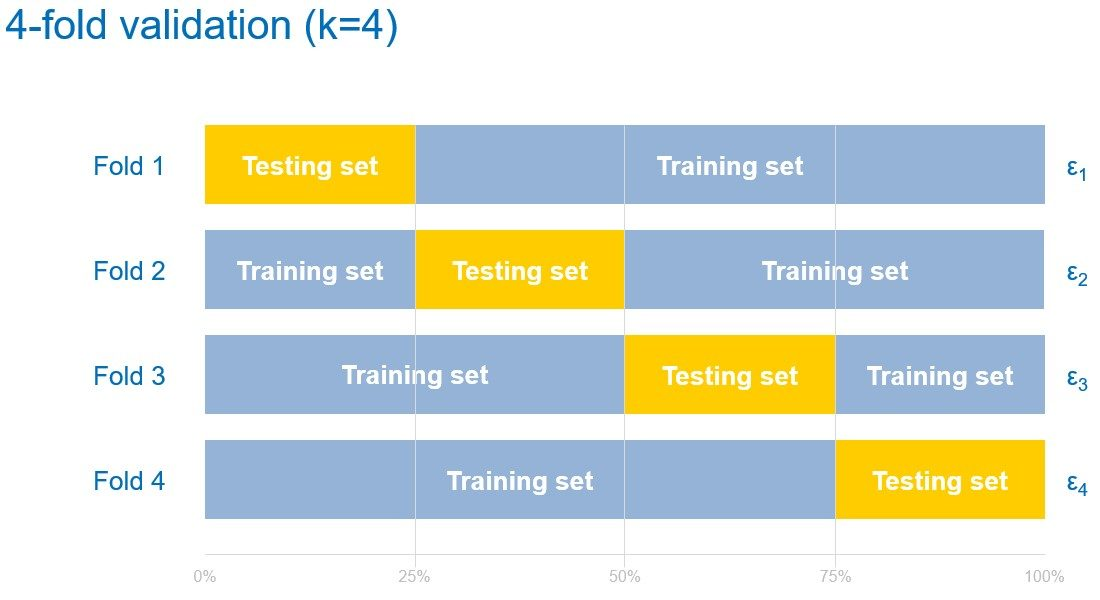


In [ ]:
'''
cross_val_score randomly splits the training set into 10 distinct subsets called folds, then it
trains and evaluates the Decision Tree model 10 times, picking a different fold for
evaluation every time and training on the other 9 folds.
'''

from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, rentals_prepared, rentals_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

In [ ]:
lin_scores = cross_val_score(lin_reg, rentals_prepared, rentals_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(rentals_prepared, rentals_labels)

In [ ]:
rentals_predictions = forest_reg.predict(rentals_prepared)
forest_mse = mean_squared_error(rentals_labels, rentals_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

In [ ]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, rentals_prepared, rentals_labels,
                                scoring="neg_mean_squared_error", cv=5)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(rentals_prepared, rentals_labels)

GridSearch and Pipeline can be combined.

The estimator can be a parameter as well of the grid.
It is possible to access the different parameters of each estimator as we saw before.

In [ ]:

pipeline = Pipeline(steps=[('preprocessor',full_pipeline),('regressor',RandomForestRegressor(random_state=42))])

In [ ]:
params = [
    {'preprocessor': [full_pipeline],
     'regressor': [LinearRegression()],
     'regressor__fit_intercept': [True]},
    {'preprocessor': [full_pipeline],
     'regressor': [RandomForestRegressor(random_state=42)],
     'regressor__n_estimators': [10, 20],
     'regressor__min_samples_split': [5, 10]},
]
grid_search = GridSearchCV(pipeline, params, cv=3,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(rentals, rentals_labels)

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.best_estimator_

In [ ]:
cvres = pd.DataFrame(grid_search.cv_results_)
print(cvres.columns)
cvres['sqrt'] = np.sqrt(-cvres['mean_test_score'])
cvres.sort_values(by='sqrt',ascending=True)

In [ ]:

grid_search.best_estimator_

In [ ]:
'''
Once we get the best estimator we can check -- at least for some models -- the feature importance.
Such as which are the features that are __more used__ to make the predictions.
'''

best_reg = grid_search.best_estimator_["regressor"]
if not hasattr(best_reg, "feature_importances_"):
    print(
        f"Best model is {type(best_reg).__name__}; "
        "feature importances are only defined for tree-based regressors in this example."
    )
else:
    feature_importances = best_reg.feature_importances_
    feature_importances

    extra_attribs = ["sqm_per_room", "age", "bedrooms_per_room"]
    cat_encoder = full_pipeline.named_transformers_["cat"]
    cat_one_hot_attribs = []
    for col, cats in zip(cat_attribs, cat_encoder.categories_):
        cat_one_hot_attribs += [f"{col}={c}" for c in cats]
    attributes = num_attribs + extra_attribs + cat_one_hot_attribs
    sorted(zip(feature_importances, attributes), reverse=True)


## Classification

Now we prove how good we are in a classification tasks.

Given a set of drawn digits we want to predict if the image is a 5 or not.

This is a problem of BINARY CLASSIFICATION

We will study which are the quality measures that we need to take into account to improve the perfomance of our model.
 - Confusion matrix
 - Precision vs Recall
 - F1
 - ROC and AUC

In [ ]:
'''
We gathered the MNIST Dataset from the dataset available directly on scikit
'''

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

In [ ]:
'''
Let's explore some property of this dataset.
'''

X, y = mnist["data"], mnist["target"]
X.shape

In [ ]:
'''
And how it looks like
'''

import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

# save_fig("some_digit_plot")
plt.show()

In [ ]:
'''
y contains the label for each image
'''

y[0]

In [ ]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [ ]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

In [ ]:
'''
Some more images, just to have an idea of the content
'''
plt.figure(figsize=(9,9))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
# save_fig("more_digits_plot")
plt.show()

In [ ]:
'''
In this case, we don't use any scikit function to create training and test.
We simply take the first 60000 as training and the remaining as test.
'''

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [ ]:
'''
As I said before, just to start and to understand some metrics tipically used
We build a binary class: it's a 5 or not.

Therefore, we will train a model to predict if a given image is a 5 or not.
'''

y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [ ]:

y_train_5

### Select the best evaluation metrics!
- Accuracy?
- Some others?

In [ ]:
'''
We try a Stochastic Gradient Descent algorithm
'''

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train_5)

```python
class sklearn.linear_model.SGDClassifier(loss='hinge', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001,
shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.5, early_stopping=False,
validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)[source]¶
```

In [ ]:
sgd_clf.predict([some_digit])

In [ ]:
'''
Let's try a cross validation, as we did it before.

- Notice that we use as scoring metrics the ACCURACY
'''

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [ ]:
'''
Our classifier seems working pretty good.

And if define a classifier that predicts always false?

'''


from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [ ]:
'''
The model accuracy is pretty high also for this simple classifier, greater than 90%

Probably the accuracy is not the right metrics to use.
'''

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [ ]:
'''
We can check how our classifier predicts all the instances w.r.t. the real label

This is represented as matrix called Confusion Matrix.

Each row represents an actual class
Each column represents the predicted class
_____________
|     |     |
| TP  | FP  |
|_____|_____|
|     |     |
| FN  | TN  |
|_____|_____|

The diagonal contains the correctly labelled instances

'''

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

confusion_matrix(y_train_5, y_train_pred)

In [ ]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

#### Precision and Recall


- Precision
  - accuracy of the positive predictions
  - $TP/(TP+FP)$
  - ```from sklearn.metrics import precision_score```

- Recall
  - ratio of positive instances that are correctly detected by the classifier
  - $TP/(TP+FN)$
  - also called _sensitivity_
  - ```from sklearn.metrics import recall_score```

- F1
  - The harmonic mean between Precision and Recall
  - $2 * (Precision*Recall)/(Precision+Recall)$
  - ```from sklearn.metrics import f1_score```

In [ ]:
from sklearn.metrics import precision_score, recall_score

print('Precision score: {}'.format(precision_score(y_train_5, y_train_pred)))

cm = confusion_matrix(y_train_5, y_train_pred)
print('Precision score: {}'.format(cm[1, 1] / (cm[0, 1] + cm[1, 1])))



In [ ]:
print('Recall score: {}'.format(recall_score(y_train_5, y_train_pred)))
print('Recall score: {}'.format(cm[1, 1] / (cm[1, 0] + cm[1, 1])))

In [ ]:
from sklearn.metrics import f1_score

print('F1 score: {}'.format(f1_score(y_train_5, y_train_pred)))
print('F1 score: {}'.format(cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)))

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

There are cases in which for the final goal of the project is better to have a higher precision, while in others it is better to increase the recall.

In order to find a good balance between them, we will explore some techniques that can be used in your future projects:

- Precision/Recall curve
- ROC and AUC

They both use the fact that scikit classifiers
compute a score based on a _decision function_ (or predict_proba),
and if that score is greater than a threshold, it assigns the instance to the positive class, or else it assigns it to the negative class.

- Precision/Recall curve
  - Varying the threshold use to classify an instance, it plots for each value the relative precision and recall, so that we can identify the right threshold to have a certain precision (recall).

- ROC
  - true positive rate (another name for recall) against the false positive rate (FPR) . The FPR is the ratio of negative instances that are incorrectly classified as positive. It is equal to one minus the true negative rate,
which is the ratio of negative instances that are correctly classified as negative. The TNR is also called _specificity_.
  - Also called sensitivity vs specificity

- To compare two classifiers we use the Area Under the Curve (AUC)
A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.


In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)
    plt.axis([-50000, 50000, 0, 1])



recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")
plt.plot([-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")
plt.plot([threshold_90_precision], [recall_90_precision], "ro")
#save_fig("precision_recall_vs_threshold_plot")
plt.show()

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
# save_fig("precision_vs_recall_plot")
plt.show()

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [ ]:
precision_score(y_train_5, y_train_pred_90)

In [ ]:
recall_score(y_train_5, y_train_pred_90)

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
#save_fig("roc_curve_plot")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [ ]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

In [ ]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)
#save_fig("roc_curve_comparison_plot")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier

pipeline = Pipeline(steps=[('classifier',RandomForestClassifier())])

params = [
        {
         'classifier': [GradientBoostingClassifier(random_state=42)],
         'classifier__max_depth':[10],
         'classifier__n_estimators': [10,20],
         'classifier__n_iter_no_change':[10],
         'classifier__learning_rate':[0.1,1]
        },
    {
          'classifier': [XGBClassifier(random_state=42)],
         'classifier__n_estimators': [10,20],
          'classifier__learning_rate':[0.1,1]
        },
          # {
          #  'classifier': [RandomForestClassifier(random_state=42)],
          #  'classifier__n_estimators':[10,20],
          #  'classifier__min_samples_split':[4],
          # }
]

grid_search = GridSearchCV(pipeline, params, verbose=10, n_jobs=3,scoring='roc_auc',cv=3).fit(X_train[:1000], y_train_5[:1000])


In [ ]:
grid_search.best_estimator_

In [ ]:
cv = pd.DataFrame(grid_search.cv_results_)

In [ ]:
cv

Let's try our checklist on a new dataset

Titanic -- well known dataset available from Kaggle

In [ ]:
# Titanic CSVs next to the Milan data (Colab/local), or OpenML fallback when missing
candidate_titanic_dirs = [
    pathlib.Path("data/titanic"),
    pathlib.Path("../../../data/titanic"),
    DATA_DIR.parent / "titanic",
    pathlib.Path("/content/drive/Shareddrives/phd_hands_on/data/titanic"),
]
if any((d / "train.csv").exists() for d in candidate_titanic_dirs):
    TITANIC_DIR = next(d for d in candidate_titanic_dirs if (d / "train.csv").exists())
    training = pd.read_csv(TITANIC_DIR / "train.csv")
    test = pd.read_csv(TITANIC_DIR / "test.csv")
else:
    from sklearn.datasets import fetch_openml
    full = fetch_openml("titanic", version=1, as_frame=True, parser="auto").frame
    ix = np.random.default_rng(42).permutation(len(full))
    cut = int(0.8 * len(full))
    training = full.iloc[ix[:cut]].reset_index(drop=True)
    test = full.iloc[ix[cut:]].reset_index(drop=True)


In [ ]:
# train/test DataFrames are in `training` and `test`
